# Figure 3 Supplemental S7 — Extended analysis of omission related activity

Split out from `figure_3_supplemental.ipynb`. Contains shared setup, the standalone omission plots that feed the S7 composite, the shared SVM decoding cell (panel G), and the S7 composite assembly.

### Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import seaborn as sns
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 2})

# Statistical analysis
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from scipy.stats import chi2

# Data access
from visual_behavior.data_access import loading as loading
import visual_behavior.data_access.utilities as utilities
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorOphysProjectCache

# Utilities
import visual_behavior.visualization.utils as utils
import visual_behavior.visualization.ophys.platform_paper_figures as ppf

# NOTE: %autoreload 2 was removed -- it reloads the entire visual_behavior +
# allensdk module tree before EVERY cell, which destabilizes and kills the
# kernel on these heavy-loading notebooks (dies at a random cell each run). To
# hot-reload just your plotting code while developing, without the crash, use:
#     %load_ext autoreload
#     %autoreload 1
#     %aimport visual_behavior.visualization.ophys.platform_paper_figures
%matplotlib inline

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/xarray/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain 

### Configuration

In [2]:
# When True, skip heavy-duty loading + slow-MLM heatmaps, exposure,
# active/passive, epoch, and image-selectivity analyses (fast iteration).
skip_slow_plots = False

save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_3_supplemental')
folder = 'population_activity'

# Create save directories if they don't exist
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

if not os.path.exists(os.path.join(save_dir, folder)):
    os.makedirs(os.path.join(save_dir, folder))

palette = utils.get_experience_level_colors()
experience_levels = utils.get_new_experience_levels()
experience_level_colors = utils.get_experience_level_colors()
cell_types = utils.get_cell_types()

### Data Loading

#### Metadata tables

In [3]:
# AllenSDK cache
platform_cache_dir = loading.get_platform_analysis_cache_dir()
cache = loading._get_cache()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, 'all_ophys_experiments_table.csv'), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_experiments_table.csv'), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_ophys_cells_table.csv'), index_col=0)
behavior_sessions = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_behavior_sessions_table.csv'), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, 'platform_paper_matched_ophys_cells_table.csv'), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()
experience_levels = utils.get_experience_levels()
palette = utils.get_experience_level_colors()


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

#### Load data tables

In [4]:
data_type = 'filtered_events'
session_subset = 'full_session'
inclusion_criteria = 'platform_experiment_table'

metrics_dir = loading.get_cell_metrics_dir()
filepath = os.path.join(metrics_dir, f'merged_model_free_metrics_table_{data_type}_{inclusion_criteria}.csv')
filtered_events_metrics_table = pd.read_csv(filepath, index_col=0)

metrics_table = filtered_events_metrics_table.copy()

# Merge with platform experiments
metrics_table = metrics_table.merge(platform_experiments.reset_index(),
                                   on=['ophys_experiment_id', 'experience_level'])


# # Create event-type specific dataframes
# image_mdf = metrics_table[(metrics_table.event_type == 'images')]
# change_mdf = metrics_table[(metrics_table.event_type == 'changes')]
# omission_mdf = metrics_table[(metrics_table.event_type == 'omissions')]

# # Create each_image specific dataframe
# each_image_mdf = metrics_table[(metrics_table.event_type == 'images') &
#                                (metrics_table.image_id.notna())].copy()

In [5]:
data_type = 'events'
interpolate = True
output_sampling_rate = 30
inclusion_criteria = 'platform_experiment_table'


In [6]:

# Image changes
event_type = 'all'
conditions = ['cell_specimen_id', 'is_change']
is_change_mdf = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

change_mdf = is_change_mdf[is_change_mdf.is_change == True]
image_mdf = is_change_mdf[is_change_mdf.is_change == False]

# Omissions
conditions = ['cell_specimen_id', 'omitted']
omission_mdf = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

omission_mdf = omission_mdf[omission_mdf.omitted == True]

# Per image
conditions = ['cell_specimen_id', 'is_change', 'image_name']
each_image_mdf = loading.get_multi_session_df_for_conditions(
    data_type, event_type, conditions, inclusion_criteria,
    interpolate=interpolate, output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_platform_experiment_table.feather
there are 1881 experiments in the full multi_session_df
there are 400 experiments in the multi_session_df after limiting to platform experiments
there are 400 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_omitted_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_omitted_platform_experiment_table.feather
there are 1879 experiments in the full multi_session_df
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_image_name_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_image_name_platform_experiment_table.feather
there are 1885 experiments in the full multi_session_df
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


## Omission response characterization

Population average responses and single-cell heatmaps aligned to image omissions
across experience levels, for matched and unmatched cells. Includes omission
response magnitude by cohort, area, and depth, omission modulation index
distributions, and fraction of cells with significant omission responses. Also
includes population decoding of omission vs. pre-omission gray screen activity
and time-resolved decoding accuracy. Corresponds to PPT Figure S8 panels A-M.

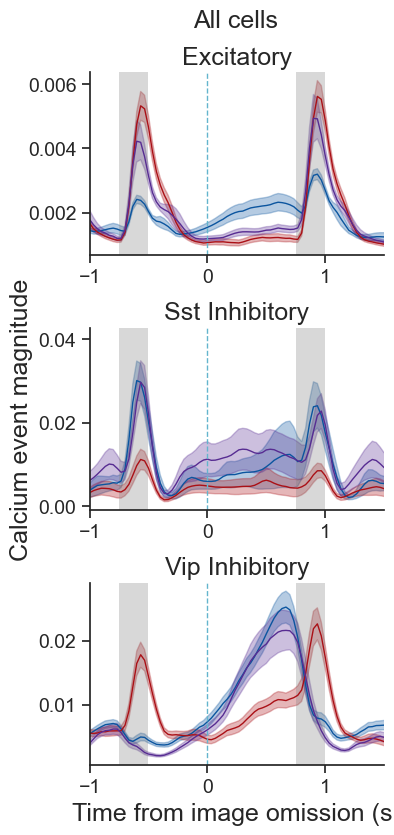

In [7]:
# population averages for omisisons
xlim_seconds = [-1., 1.5]

axes_column = 'cell_type'
hue_column = 'experience_level'

ax = ppf.plot_population_averages_for_conditions(
    omission_mdf, data_type, 'omissions', axes_column, hue_column,
    ylabel='Calcium event magnitude', sharey=False,
    horizontal=False, xlabel='Time from image omission (s)',
    xlim_seconds=xlim_seconds, interval_sec=1, legend=False,
    palette=palette, ax=None, title=None, suptitle='All cells',
    save_dir=save_dir, suffix='_omissions_all_cells')

array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\ncells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\ncells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\ncells'>,
       <Axes: xlabel='Time from omission (s)'>, <Axes: >], dtype=object)

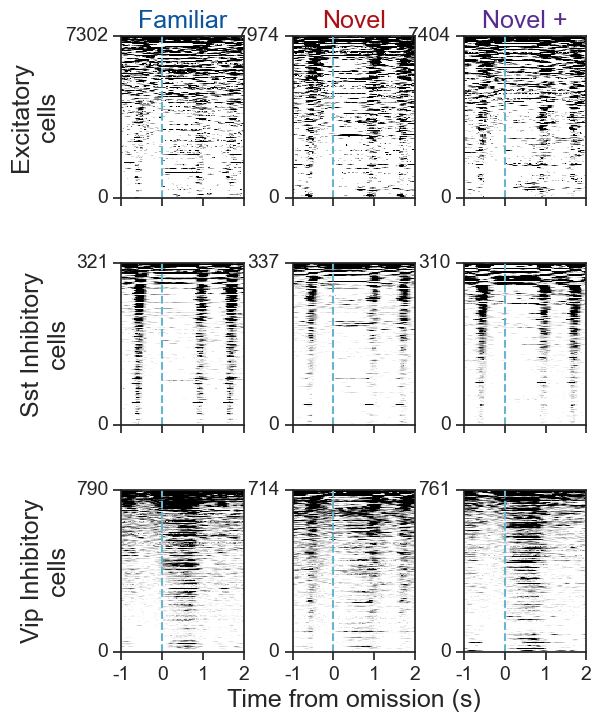

In [8]:
# Population averages for omissions - heatmaps
timestamps = omission_mdf.trace_timestamps.values[0]
row_condition = 'cell_type'
col_condition = 'experience_level'

ppf.plot_response_heatmaps_for_conditions(
    omission_mdf, timestamps, data_type, 'omissions', row_condition, col_condition,
    col_to_sort_by='mean_baseline', suptitle='Omission responses',
    xlabel='Time from omission (s)', exp_to_match='Familiar', matched_cells_table=None,
    microscope=None, xlim_seconds=[-1, 2], match_cells=False, cbar=False,
    save_dir=save_dir, suffix='_omissions', ax=None)

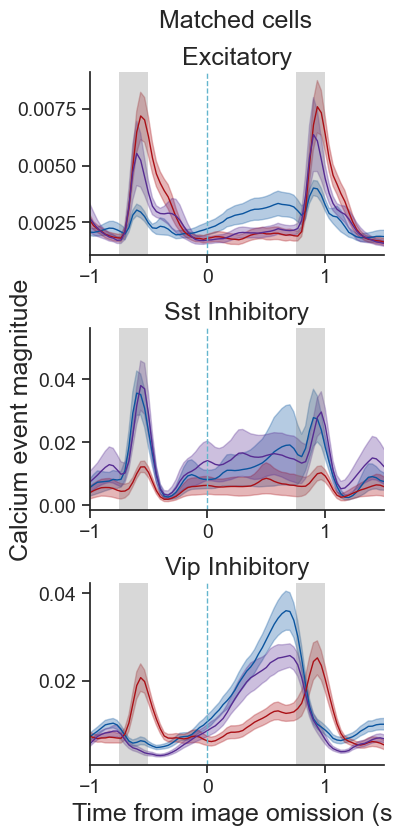

In [9]:
# population averages for omisisons
xlim_seconds = [-1., 1.5]

axes_column = 'cell_type'
hue_column = 'experience_level'

df = omission_mdf[omission_mdf.cell_specimen_id.isin(matched_cells_table.cell_specimen_id)]

ax = ppf.plot_population_averages_for_conditions(
    df, data_type, 'omissions', axes_column, hue_column,
    ylabel='Calcium event magnitude', sharey=False, 
    horizontal=False, xlabel='Time from image omission (s)',
    xlim_seconds=xlim_seconds, interval_sec=1, legend=False,
    palette=palette, ax=None, title=None, suptitle='Matched cells',
    save_dir=save_dir, suffix='_omissions_matched_cells')

array([<Axes: title={'center': 'Familiar'}, ylabel='Excitatory\nmatched cells'>,
       <Axes: title={'center': 'Novel'}>,
       <Axes: title={'center': 'Novel +'}>,
       <Axes: ylabel='Sst Inhibitory\nmatched cells'>, <Axes: >, <Axes: >,
       <Axes: ylabel='Vip Inhibitory\nmatched cells'>,
       <Axes: xlabel='Time from omission (s)'>, <Axes: >], dtype=object)

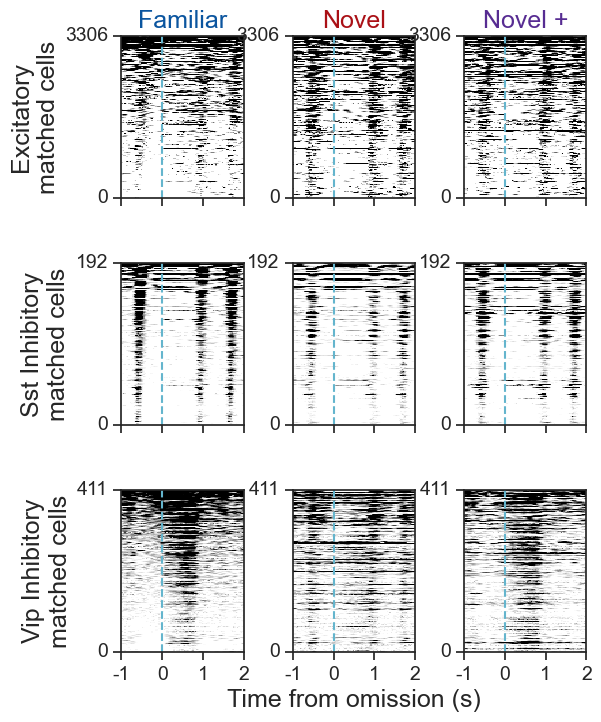

In [10]:
# Cell-matched omission heatmaps
matched_omissions = utilities.limit_to_cell_specimen_ids_matched_in_all_experience_levels(omission_mdf)
matched_omissions = utilities.limit_to_last_familiar_second_novel_active(matched_omissions)

ppf.plot_response_heatmaps_for_conditions(
    matched_omissions, timestamps, data_type, 'omissions', row_condition, col_condition,
    col_to_sort_by='mean_baseline', suptitle='Matched cells - Omissions',
    xlabel='Time from omission (s)', exp_to_match='Familiar', matched_cells_table=matched_cells_table,
    microscope=None, xlim_seconds=[-1, 2], match_cells=True, cbar=False,
    save_dir=save_dir, suffix='_matched_omissions', ax=None)

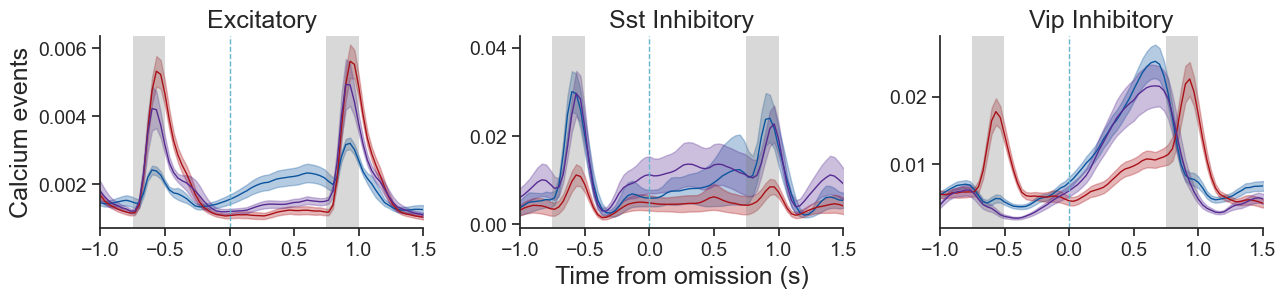

In [11]:
# Population averages for omissions across conditions
axes_column = 'cell_type'
hue_column = 'experience_level'
xlim_seconds = [-1., 1.5]

ax = ppf.plot_population_averages_for_conditions(
    omission_mdf, data_type, 'omissions', axes_column, hue_column,
    horizontal=True, xlabel='Time from omission (s)',
    ylabel='Calcium events', legend=False,
    xlim_seconds=xlim_seconds, interval_sec=0.5,
    palette=palette, ax=None, title=None, suptitle=None,
    save_dir=save_dir, suffix='_omissions')

#### Fraction responsive cells 

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/

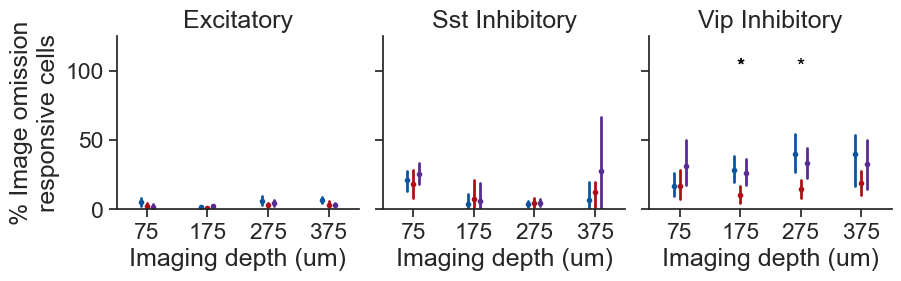

In [12]:
df = omission_mdf.copy()
fraction_responsive = ppf.get_fraction_responsive_cells(df, conditions=['cell_type', 'experience_level', 'ophys_container_id', 'ophys_experiment_id'],
                                                        responsiveness_threshold=0.1)
fraction_responsive = fraction_responsive.reset_index()
fraction_responsive = fraction_responsive.merge(platform_experiments[['ophys_container_id', 'binned_depth', 'imaging_depth']], on='ophys_container_id')
fraction_responsive = fraction_responsive.drop_duplicates(subset=['ophys_container_id', 'ophys_experiment_id'])
fraction_responsive['percent_responsive'] = fraction_responsive['fraction_responsive']*100

depths = np.sort(fraction_responsive.binned_depth.unique())

cell_types = utils.get_cell_types()
figsize = (10, 2.25)
fig, ax = plt.subplots(1, 3, figsize=figsize, sharey=True)
ax = ax.ravel()
for i, cell_type in enumerate(cell_types): 
    data = fraction_responsive[fraction_responsive.cell_type==cell_type]
    ax[i] = sns.pointplot(data=data,
                    x='binned_depth', y='percent_responsive', hue='experience_level', linestyle='none', order=depths,
                    markers='.', markersize=4, err_kws={'linewidth': 2}, palette=experience_level_colors, dodge=0.2, ax=ax[i])
    ax[i].set_title(cell_type)
    # ax[i].legend(fontsize='xx-small')
    ax[i].get_legend().remove()
    ax[i].set_xlabel('Imaging depth (um)')
    ax[i].set_ylabel('% Image omission\nresponsive cells')
    ax[i].set_ylim(0, 100)

    ax[i], tukey_table = ppf.add_stats_to_plot_for_hues(data, 'percent_responsive', ax[i],
                                                            xorder=depths, x='binned_depth', hue='experience_level')
plt.subplots_adjust(wspace=0.1)

filename = 'percent_omission_responsive_cells_by_depth'
utils.save_figure(fig, figsize, save_dir, folder, filename)

#### Omission response magnitude

array([<Axes: ylabel='Excitatory'>,
       <Axes: ylabel='Mean omission response\n\nSst Inhibitory'>,
       <Axes: ylabel='Vip Inhibitory'>], dtype=object)

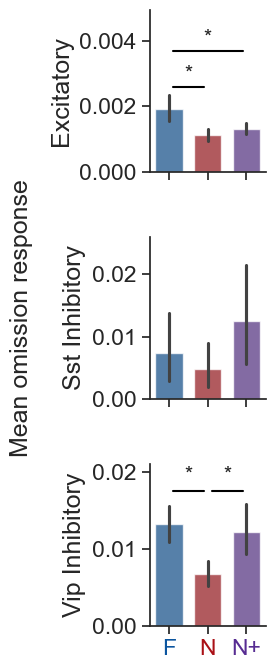

In [13]:
metric = 'mean_response_omissions'
ylabel = 'Mean omission response'

event_type = 'omissions'

ylims = None #(-0.001, 0.025)

ppf.plot_metric_distribution_by_experience(metrics_table, metric, plot_type='barplot', #show_containers=True,
                                           horiz=False, add_zero_line=False, event_type=event_type, data_type=data_type,
                                           ylabel=ylabel, ylims=ylims, save_dir=save_dir, ax=None)



/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/

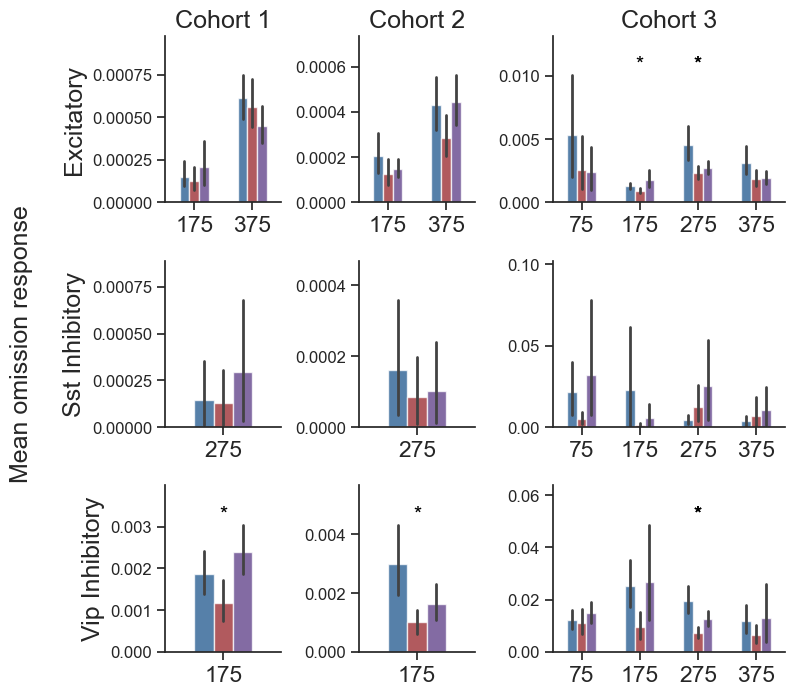

In [14]:
metric = 'mean_response_omissions'
ylabel = 'Mean omission response'
event_type = 'omissions'
x_val = 'binned_depth'

ppf.plot_metric_across_cohorts(metrics_table, metric,  ylabel, x_val=x_val, plot_type='barplot', 
                               event_type=event_type, save_dir=save_dir, ax=None);

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)


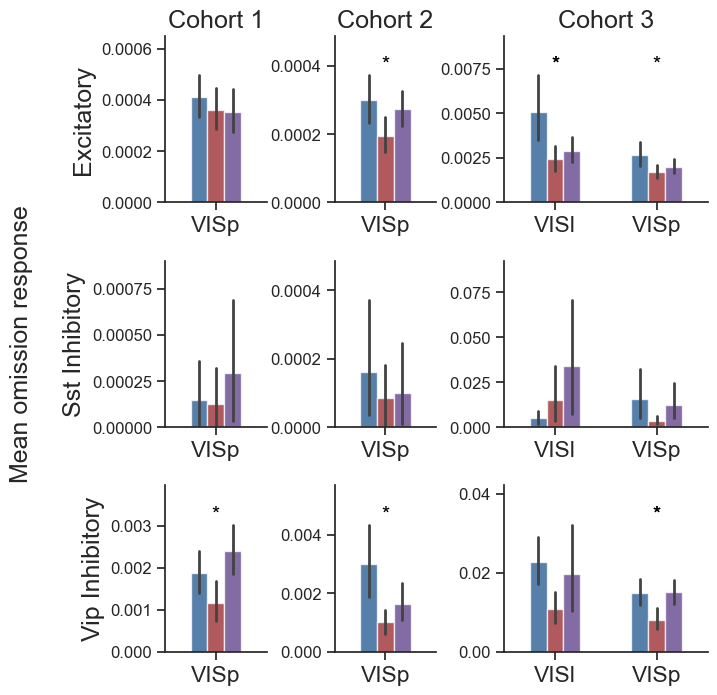

In [15]:
metric = 'mean_response_omissions'
ylabel = 'Mean omission response'
event_type = 'omissions'
x_val = 'targeted_structure'

ppf.plot_metric_across_cohorts(metrics_table, metric,  ylabel, x_val=x_val, plot_type='barplot', 
                               event_type=event_type, save_dir=save_dir, ax=None);

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/

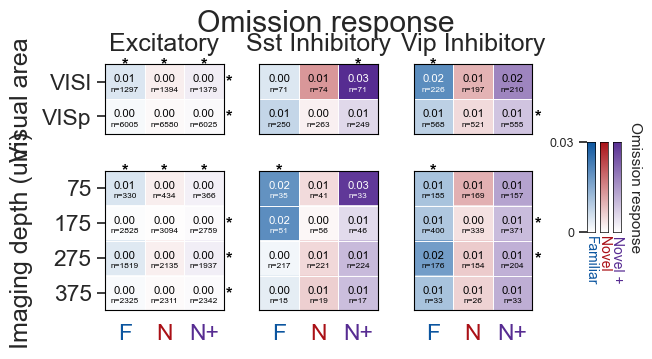

In [16]:
if not skip_slow_plots:
    ax, stats = ppf.plot_metric_heatmap_area_and_depth_by_cell_type(
        metrics_table, metric='mean_response_omissions', metric_label='Omission response',
        save_dir=save_dir, event_type='omissions')

#### Omission modulation index

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3519: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y, x=x, order=experience_levels,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3519: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y, x=x, order=experience_levels,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3519: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, y=y

array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='Omission modulation'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

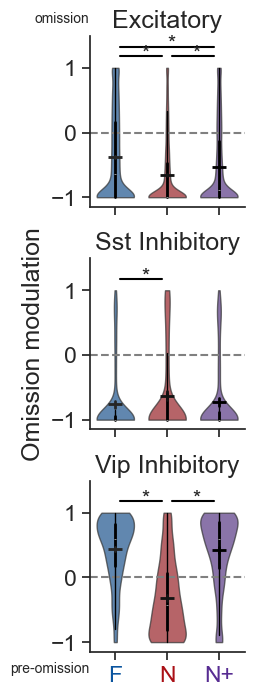

In [17]:
metric = 'omission_modulation_index'
xlabel = 'Omission modulation'
event_type = 'omissions'
annot = ('pre-omission', 'omission')
xlims = (-1.15, 1.15)

ppf.plot_modulation_index_distribution(metrics_table, metric, label=xlabel, plot_type='violinplot',
                                       lims=xlims, horiz=False, annot=annot, metric_on_y=True,
                                        abbreviate_exp=True, suptitle=None, fill=True, 
                                        save_dir=save_dir, suffix='', event_type='omissions')


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3467: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, x=x, y=y, orient=orient,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Use

array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='Omission modulation'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

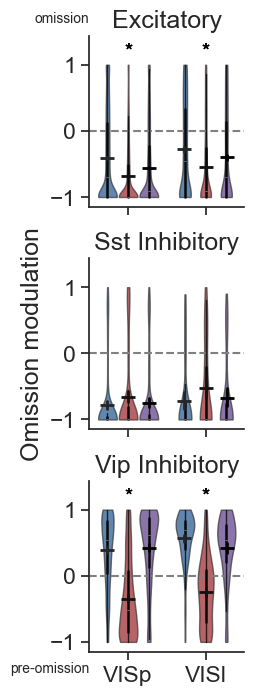

In [18]:
metric = 'omission_modulation_index'
label = 'Omission modulation'
event_type = 'omissions'
annot = ('pre-omission', 'omission')
xlims = (-1.15, 1.15)

ppf.plot_modulation_index_distribution(metrics_table, metric, x_axis_col='targeted_structure', plot_type='violinplot',
                                       label=label, lims=xlims, horiz=False, annot=annot, fill=True,
                                        abbreviate_exp=True, suptitle=None, save_dir=save_dir, suffix='', event_type='omissions')

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:3467: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.

  ax[i] = sns.pointplot(data=ct_data, x=x, y=y, orient=orient,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Use

array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}, ylabel='Omission modulation'>,
       <Axes: title={'center': 'Vip Inhibitory'}>], dtype=object)

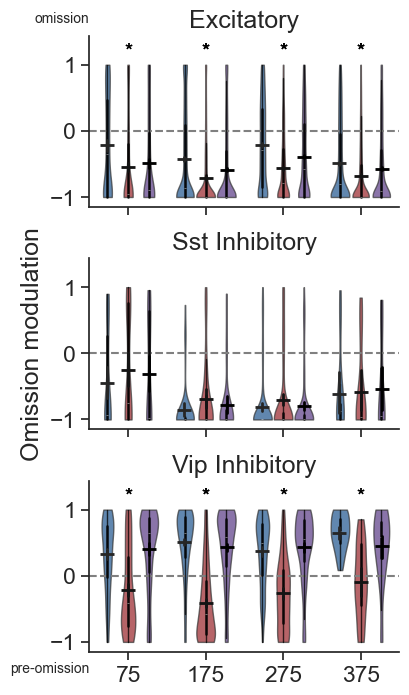

In [19]:
metric = 'omission_modulation_index'
label = 'Omission modulation'
event_type = 'omissions'
annot = ('pre-omission', 'omission')
xlims = (-1.15, 1.15)

ppf.plot_modulation_index_distribution(metrics_table, metric, x_axis_col='binned_depth', plot_type='violinplot',
                                       label=label, lims=xlims, horiz=False, annot=annot, fill=True,
                                    metric_on_y=True, abbreviate_exp=True, suptitle=None, save_dir=save_dir, suffix='', event_type='omissions')

array([<Axes: title={'center': 'Excitatory'}>,
       <Axes: title={'center': 'Sst Inhibitory'}>,
       <Axes: title={'center': 'Vip Inhibitory'}, xlabel='Experience modulation'>],
      dtype=object)

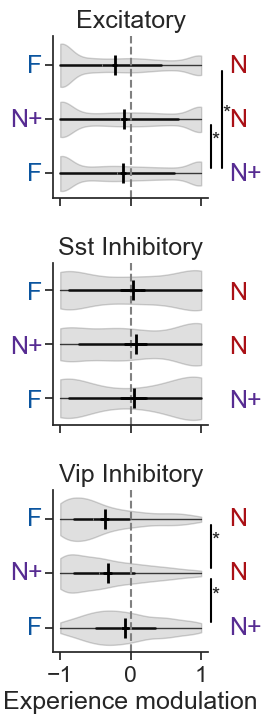

In [20]:
metric = 'mean_response'
event_type = 'omissions'
xlabel = 'Experience modulation'

ppf.plot_experience_modulation_index_annotated_by_cell_type(omission_mdf, event_type, metric, platform_cells_table,
                                                            xlims=(-1.1, 1.1), xlabel=xlabel,
                                                            all_comparisons=True, horiz=False,
                                                            suptitle=None, suffix='', save_dir=None, ax=None)

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:4162: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_yticklabels([cell_type[:3] for cell_type in cell_types])
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:4162: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_yticklabels([cell_type[:3] for cell_type in cell_types])
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:4162: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_yticklabels([cell_type[:3] for cell_type in cell_types])


array([<Axes: title={'center': 'Novel vs. Familiar'}>,
       <Axes: title={'center': 'Novel vs. Novel +'}>,
       <Axes: title={'center': 'Novel + vs. Familiar'}, xlabel='Experience modulation'>],
      dtype=object)

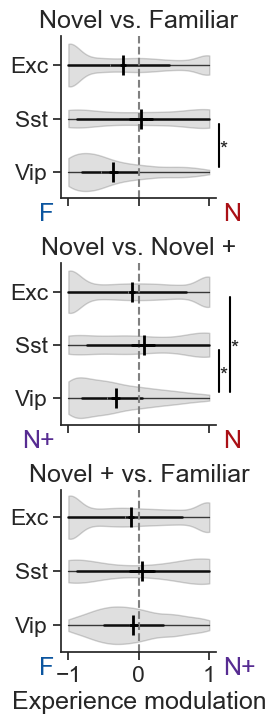

In [21]:
metric = 'mean_response'
event_type = 'omissions'
xlabel = 'Experience modulation'

ppf.plot_experience_modulation_index_annotated(
    omission_mdf, event_type, metric, platform_cells_table,
    xlabel=xlabel, xlims=(-1.1, 1.1), horiz=False,
    suptitle=None, suffix='', save_dir=save_dir, ax=None)

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/

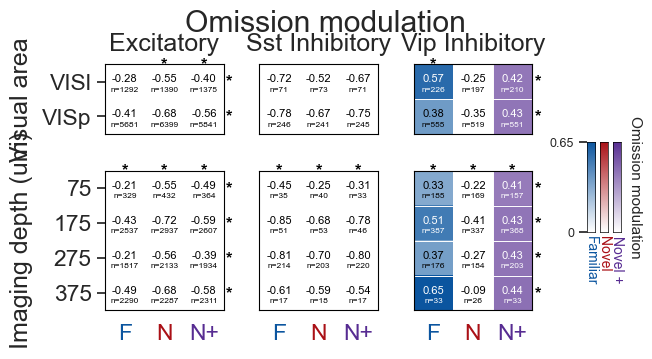

In [22]:
if not skip_slow_plots:
    ax, stats = ppf.plot_metric_heatmap_area_and_depth_by_cell_type(
        metrics_table, metric='omission_modulation_index', metric_label='Omission modulation',
        save_dir=save_dir, event_type='omissions')

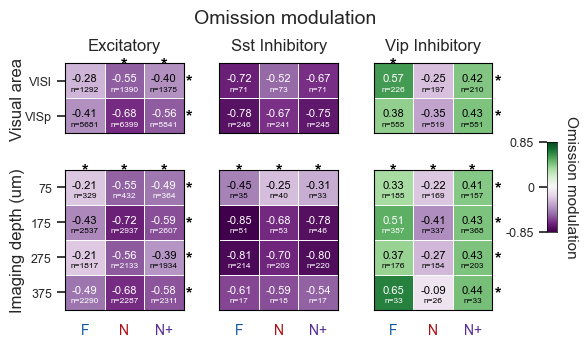

In [23]:
if not skip_slow_plots:

    ax, stats = ppf.plot_bidirectional_metric_heatmap_area_and_depth_by_cell_type(
        metrics_table, metric='omission_modulation_index', metric_label='Omission modulation',
        cmap='PRGn', save_dir=save_dir, event_type='omissions'
    )

#### Omission experience modulation by area and depth

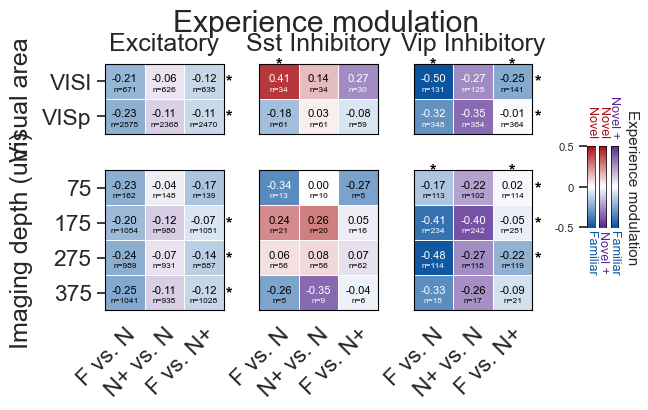

In [24]:
if not skip_slow_plots:
    metric = 'mean_response'
    event_type = 'omissions'
    xlabel = 'Experience modulation'

    ax, stats = ppf.plot_experience_modulation_heatmap_area_and_depth_by_cell_type(
        omission_mdf, event_type=event_type, metric=metric,
        cells_table=platform_cells_table,
        save_dir=save_dir, folder='metric_distributions',
    )

In [25]:
# metric = 'mean_response'
# event_type = 'omissions'
# xlabel = 'Experience modulation'

# ax3, stats_table = ppf.plot_experience_modulation_index_depth_heatmap_by_cell_type(
#     omission_mdf, event_type, metric, platform_cells_table,
#     groupby_col='binned_depth', ylabel='Imaging depth (um)', save_dir=save_dir)

# ax3, stats_table = ppf.plot_experience_modulation_index_depth_heatmap_by_cell_type(
#     omission_mdf, event_type, metric, platform_cells_table,
#     groupby_col='targeted_structure', ylabel='Visual area', save_dir=save_dir)



## SVM decoding (for S6 panel I & S7 panel G)
Loads the aggregated all_sess SVM decoding data and builds the across-project-code aggregated standalone plots. The labeled df / time axis / window metrics are stashed in `svm_agg` and reused by the S6 and S7 composite cells below.

[ok] decode_changes_from_nochanges / VisualBehavior: all_sess_events_svm_decode_changes_from_nochanges_equalTrs_frames-15to22_VisualBehavior_20220113_202511.h5
[ok] decode_changes_from_nochanges / VisualBehaviorTask1B: all_sess_events_svm_decode_changes_from_nochanges_equalTrs_frames-15to22_VisualBehaviorTask1B_20220113_202313.h5
[ok] decode_changes_from_nochanges / VisualBehaviorMultiscope: all_sess_events_svm_decode_changes_from_nochanges_equalTrs_frames-5to7_VisualBehaviorMultiscope_20220114_110349.h5
[ok] decode_baseline_from_nobaseline / VisualBehavior: all_sess_events_svm_decode_baseline_from_nobaseline_equalTrs_frames-15to22_VisualBehavior_20220113_202737.h5
[ok] decode_baseline_from_nobaseline / VisualBehaviorTask1B: all_sess_events_svm_decode_baseline_from_nobaseline_equalTrs_frames-15to22_VisualBehaviorTask1B_20220113_203011.h5
[ok] decode_baseline_from_nobaseline / VisualBehaviorMultiscope: all_sess_events_svm_decode_baseline_from_nobaseline_equalTrs_frames-5to7_VisualBehavi

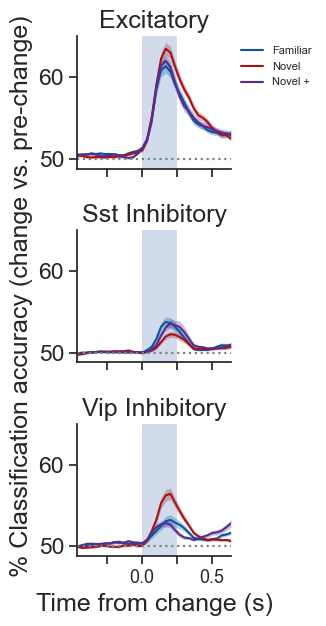

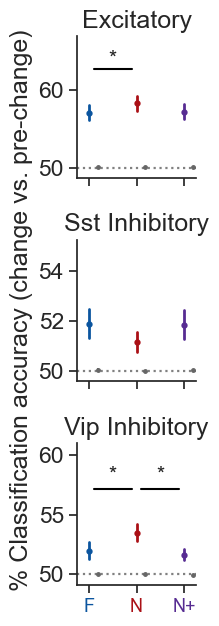

/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10903: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10903: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/platform_paper_figures.py:10903: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(Mp, 0)
/opt/miniconda3/e

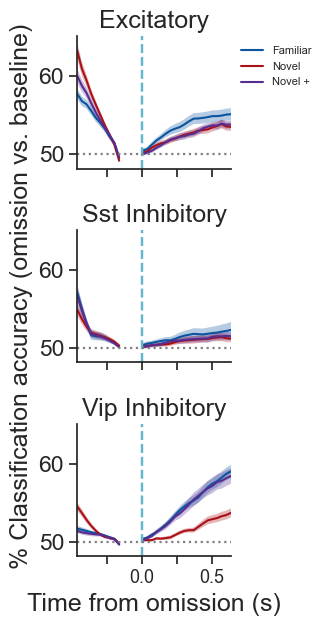

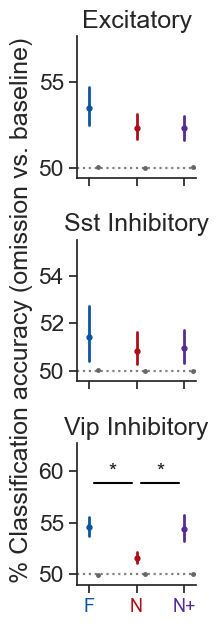

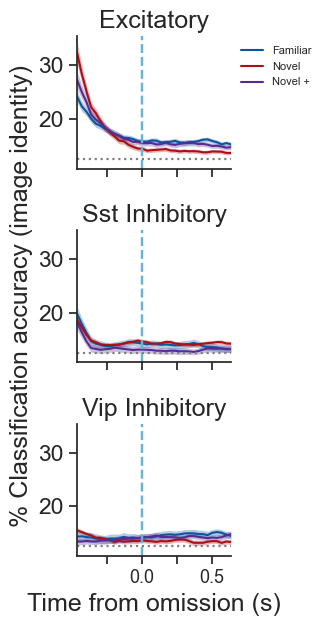

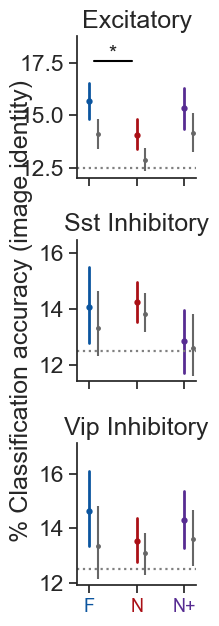

In [26]:
# ============================================================================
# SVM decoding (aggregated across project codes)
# Loads the all_sess SVM decoding aggregates and builds the across-project-code
# aggregated standalone plots for:
#   decode_changes_from_nochanges   -> Figure S6 panel I (change vs. no-change)
#   decode_baseline_from_nobaseline -> Figure S7 panel G (omission vs. gray)
#   decode_next_image_from_omissions -> Figure S8 panel F (image identity)
# The labeled df / common time axis / window metrics are stashed in `svm_agg`
# and reused by the S6 and S7 composite cells below.
# Mirrors load_svm_decoding_results.ipynb.
# ============================================================================
import re
import glob
import importlib
import matplotlib.pyplot as plt
importlib.reload(ppf)   # pick up the decoding functions added to platform_paper_figures.py

svm_project_codes = ['VisualBehavior', 'VisualBehaviorTask1B', 'VisualBehaviorMultiscope']
_svm_dir = os.path.join(loading.get_platform_analysis_cache_dir(), 'visual_behavior_ophys_decoding')
svm_metrics_dir = os.path.join(_svm_dir, 'window_metrics')

_SVM_PC_RE = re.compile(r'_(VisualBehaviorMultiscope|VisualBehaviorTask1B|VisualBehavior)_\d{8}_\d{6}\.h5$')
_SVM_TS_RE = re.compile(r'_(\d{8})_(\d{6})\.h5$')


def _svm_project_code(b):
    m = _SVM_PC_RE.search(b)
    return m.group(1) if m else None


def _svm_timestamp(b):
    m = _SVM_TS_RE.search(b)
    return (m.group(1) + m.group(2)) if m else ''


def find_svm_events_file(decoding_type, project_code):
    """Latest standard all_sess events aggregate for a (decoding_type, project_code)."""
    keep = []
    for f in glob.glob(os.path.join(_svm_dir, 'all_sess_events_svm_%s_*.h5' % decoding_type)):
        b = os.path.basename(f)
        if 'matched_cells' in b or 'sameNumNeurons' in b:
            continue
        if _svm_project_code(b) != project_code:
            continue
        keep.append(f)
    keep.sort(key=lambda f: _svm_timestamp(os.path.basename(f)))
    return keep[-1] if keep else None


svm_decoding_types = ['decode_changes_from_nochanges', 'decode_baseline_from_nobaseline',
                      'decode_next_image_from_omissions']  # last = S8 panel F (image identity)
svm_results, svm_input_vars = {}, {}
for _dt in svm_decoding_types:
    svm_results[_dt], svm_input_vars[_dt] = {}, {}
    for _pc in svm_project_codes:
        _fp = find_svm_events_file(_dt, _pc)
        if _fp is None:
            print('[missing] %s / %s' % (_dt, _pc))
            continue
        svm_results[_dt][_pc] = pd.read_hdf(_fp, key='all_sess')
        try:
            svm_input_vars[_dt][_pc] = pd.read_hdf(_fp, key='input_vars')
        except KeyError:
            svm_input_vars[_dt][_pc] = None
        print('[ok] %s / %s: %s' % (_dt, _pc, os.path.basename(_fp)))

# aggregate across project codes; build standalone figures; stash for the composites
svm_agg = {}
for _dt in svm_decoding_types:
    _combined, _t = ppf.resample_decoding_across_projects(
        svm_results, svm_input_vars, _dt, svm_project_codes)
    _labeled = ppf.add_decoding_labels(_combined, platform_experiments)
    _wm = ppf.get_decoding_window_metrics(
        _labeled, _dt, _t, metrics_dir=svm_metrics_dir, tag='aggregated', recompute=False)
    svm_agg[_dt] = dict(labeled=_labeled, t=_t, wm=_wm)
    ppf.plot_decoding_figures(_combined, _dt, platform_experiments, time_axis=_t,
                              metrics_dir=svm_metrics_dir, recompute_metrics=False)
    plt.show()


## Figure S7 composite (assembled)
Extended analysis of omission related activity.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/data_access/from_lims.py:37: UserWarning: failed to set up LIMS/mtrain credentials
'LIMS_DBNAME'

         internal AIBS users should set up environment variables         appropriately
functions requiring database access will fail
  warnings.warn(warn_string)
/Users/

OVERLAP: axes of panel "J" intrudes into panel "K" (left gutter)
OVERLAP: axes of panel "J" intrudes into panel "K" (left gutter)


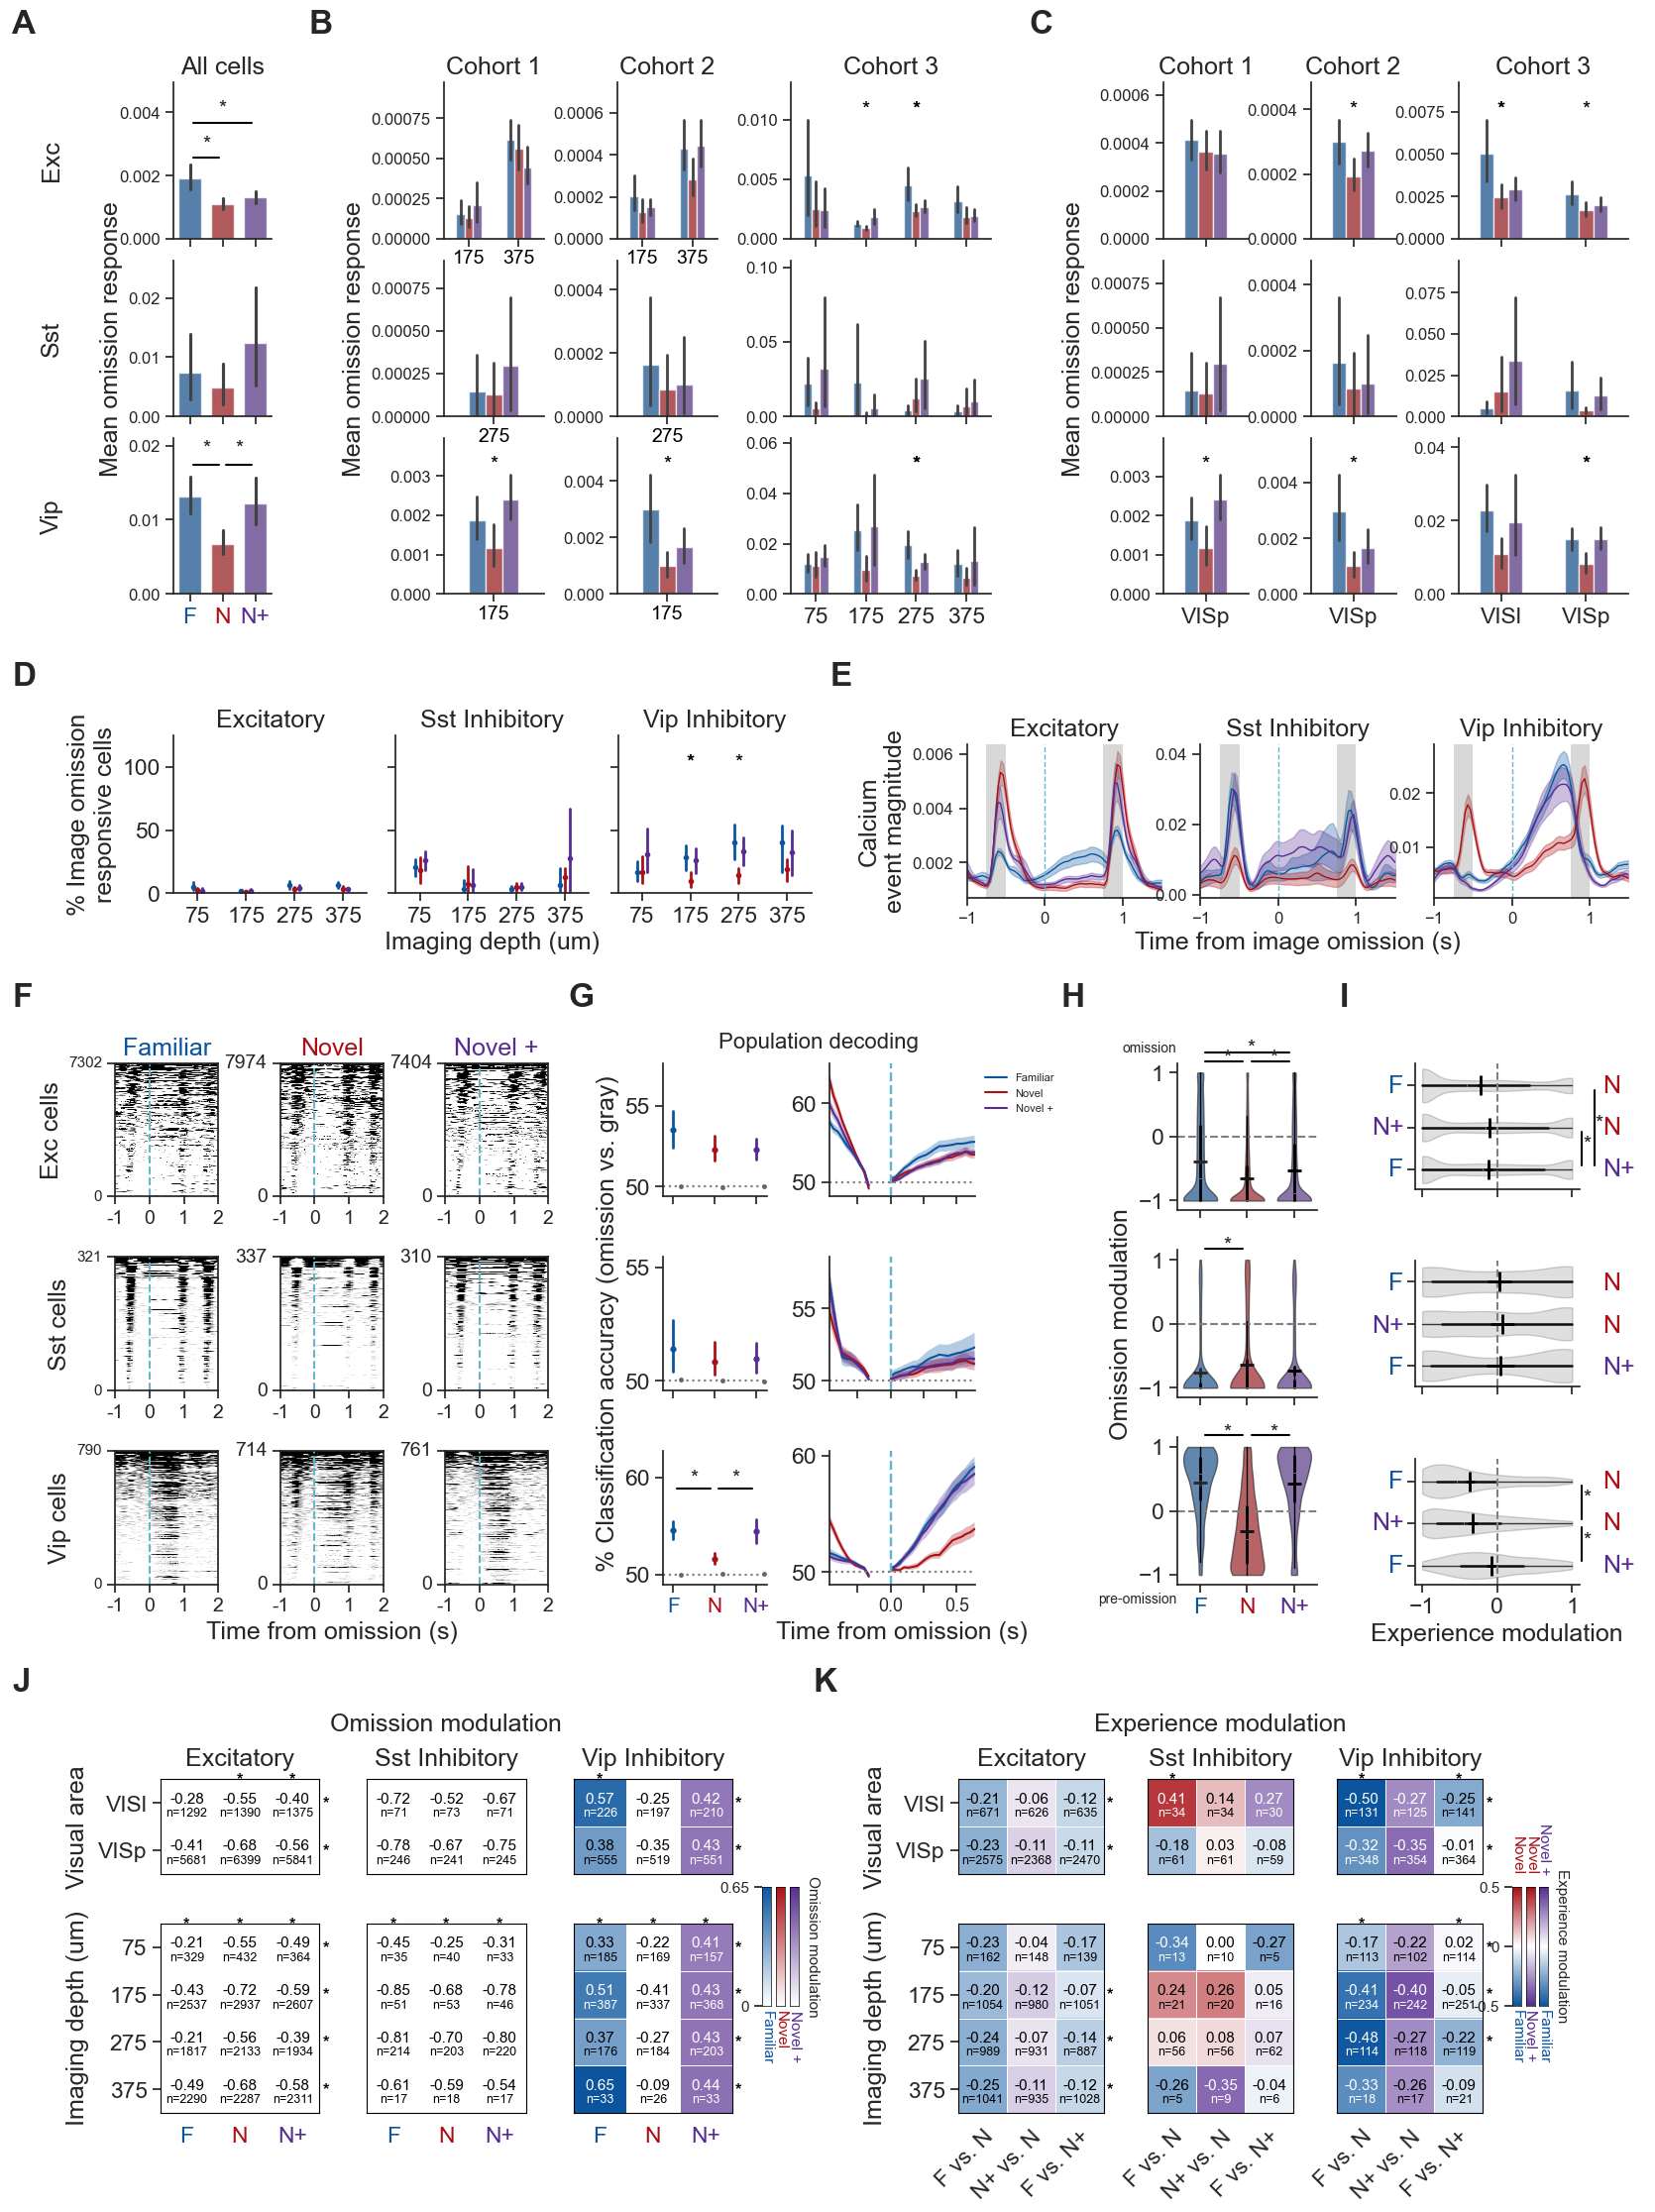

In [27]:
# ==========================================================================
# Figure S7 composite  (Extended analysis of omission related activity)
# Mirrors the S6 composite cell above: same panel_grid scaffolding + helpers,
# omission versions of each panel. REGIONS derived from the measured figure geometry
# (crop aspect 0.762 -> portrait figure).
#   A omission response | B cohort x depth | C cohort x area | D % omission responsive
#   E omission population averages | F omission heatmaps | G decoding placeholder (other notebook)
#   H omission modulation | I experience modulation | J/K modulation heatmaps (embedded)
# NOTE: restart kernel / re-run imports so the platform_paper_figures E/H/I
# side-effect guards load before rendering.
# ==========================================================================
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from visual_behavior.visualization.panel_grid import (
    fig_setup, panel, show_label_gutters, check_label_overlap,
    auto_fit_bottom, snug_left_to_gutter, snug_top_to_gutter)

sns.set_context('notebook', font_scale=1.5)

FIGSIZE = (16.5, 21.6)
REGIONS = {
    'A': [0.0,   0.161, 0.0,   0.287], 'B': [0.185, 0.601, 0.0,   0.287],
    'C': [0.625, 0.992, 0.0,   0.287],
    'D': [0.0,   0.49, 0.305, 0.440], 'E': [0.5, 0.992, 0.309, 0.440],
    'F': [0.0,   0.335, 0.458, 0.762], 'G': [0.340, 0.59, 0.458, 0.762],
    'H': [0.647, 0.801, 0.458, 0.762], 'I': [0.814, 0.960, 0.458, 0.762],
    'J': [0.002, 0.55, 0.774, 0.98],   'K': [0.49, 1.45, 0.774, 0.98],
}
CT = utils.get_cell_types()
WSPACE_BC, WSPACE_F = 0.55, 0.6
LEFT_MARGIN_DEC = 90   # shared left decoration (pt); aligns A/D/F left spines
A_LEFT_DEC = 90        # A starts further right (thin column; gap to its row labels)


def _hide_inner_xticklabels(grid):
    rows = grid if isinstance(grid[0], (list, tuple, np.ndarray)) else [[a] for a in grid]
    for r, row in enumerate(rows):
        if r < len(rows) - 1:
            for a in row:
                a.tick_params(labelbottom=False)


def _single_metric_ylabel(grid, metric_label):
    rows = grid if isinstance(grid[0], (list, tuple, np.ndarray)) else [[a] for a in grid]
    for row in rows:
        for a in row:
            a.set_ylabel('')
    rows[len(rows) // 2][0].set_ylabel(metric_label)


def _cohort_width_ratios(x_val):
    e = metrics_table[metrics_table.cell_type == 'Excitatory']
    return [len(np.sort(e[e.project_code == pc][x_val].dropna().unique()))
            for pc in metrics_table.project_code.unique()]

def _annotate_cohort_xvals(grid, x_val, rows=(0, 1, 2), cols=(0, 1), fontsize=14, color='k', dy=-8):
    # Cohorts 1 & 2 use different depths per cell type, so each subplot's x-tick labels are
    # blanked (un-hiding them would force inter-row whitespace) and the depth is printed in the
    # x-tick-label position (just below the axis) instead -- consistent across all three rows.
    # Categories come from the data (tick-label text reads back blank before the first draw).
    cts = utils.get_cell_types()
    pcs = list(metrics_table.project_code.unique())   # column order matches plot_metric_across_cohorts
    for _r in rows:
        for _c in cols:
            _ax = grid[_r][_c]
            _ax.set_zorder(5 - _r)               # raise upper rows so their labels draw over the axis below
            _ax.tick_params(labelbottom=False)   # blank x-tick labels; the annotation replaces them
            _data = metrics_table[(metrics_table.cell_type == cts[_r]) &
                                  (metrics_table.project_code == pcs[_c])]
            for _xpos, _cat in enumerate(np.sort(_data[x_val].unique())):   # seaborn category positions = 0,1,2,...
                if isinstance(_cat, float) and np.isnan(_cat):
                    continue
                try:
                    _lab = str(int(round(float(_cat))))     # depth -> integer um
                except (ValueError, TypeError):
                    _lab = str(_cat)                        # area -> name
                _an = _ax.annotate(_lab, xy=(_xpos, 0), xycoords=('data', 'axes fraction'),
                                   xytext=(0, dy), textcoords='offset points',
                                   ha='center', va='top', fontsize=fontsize, color=color, zorder=10)
                _an.set_clip_on(False)

ts_omission = omission_mdf.trace_timestamps.values[0]
fig = plt.figure(figsize=FIGSIZE)
fig_setup(fig)

# ---- A: mean omission response (3x1; cell type each row, metric on MIDDLE) ----
axA = panel(fig, REGIONS['A'][:2], REGIONS['A'][2:], 'A', has_title=True, dim=(3, 1),
            decoration_pt=(A_LEFT_DEC, 0))
ppf.plot_metric_distribution_by_experience(
    metrics_table, 'mean_response_omissions', event_type='omissions', data_type=data_type,
    plot_type='barplot', horiz=False, add_zero_line=False, ylabel='Mean omission response',
    ylims=None, save_dir=None, ax=axA)
for a in axA:
    a.set_ylabel('')
axA[1].set_ylabel('Mean omission response')
axA[0].set_title('All cells')
_hide_inner_xticklabels(axA)
for a in axA:
    a.tick_params(axis='y', labelsize=12)

# ---- B: omission response by cohort x imaging depth (3x3; x shared down columns) ----
axB = panel(fig, REGIONS['B'][:2], REGIONS['B'][2:], 'B', has_title=True, dim=(3, 3),
            sharex='col', sharey=False, wspace=WSPACE_BC, width_ratios=_cohort_width_ratios('binned_depth'))
ppf.plot_metric_across_cohorts(
    metrics_table, 'mean_response_omissions', 'Mean omission response',
    x_val='binned_depth', plot_type='barplot', event_type='omissions', save_dir=None,
    ax=list(np.array(axB).ravel()))
_single_metric_ylabel(axB, 'Mean omission response')
_hide_inner_xticklabels(axB)
_annotate_cohort_xvals(axB, 'binned_depth')  # depth labels for Exc/Sst/Vip, cohorts 1-2

# ---- C: omission response by cohort x visual area (3x3) ----
axC = panel(fig, REGIONS['C'][:2], REGIONS['C'][2:], 'C', has_title=True, dim=(3, 3),
            sharey=False, wspace=WSPACE_BC, width_ratios=_cohort_width_ratios('targeted_structure'))
ppf.plot_metric_across_cohorts(
    metrics_table, 'mean_response_omissions', 'Mean omission response',
    x_val='targeted_structure', plot_type='barplot', event_type='omissions', save_dir=None,
    ax=list(np.array(axC).ravel()))
_single_metric_ylabel(axC, 'Mean omission response')
_hide_inner_xticklabels(axC)

# ---- D: % omission responsive cells by depth (1x3; shared y) ----
axD = panel(fig, REGIONS['D'][:2], REGIONS['D'][2:], 'D', has_title=True, dim=(1, 3),
            sharey=True, wspace=0.15, decoration_pt=(LEFT_MARGIN_DEC, 0))
ppf.plot_percent_responsive_cells_by_depth(omission_mdf, 'omissions', platform_experiments, ylabel='% Image omission\nresponsive cells', save_dir=None, ax=list(np.array(axD).ravel()))
for j, a in enumerate(np.array(axD).ravel()):
    a.set_xlabel('Imaging depth (um)' if j == 1 else '')

# ---- E: omission population averages by cell type x experience level (1x3) ----
axE = panel(fig, REGIONS['E'][:2], REGIONS['E'][2:], 'E', has_title=True, dim=(1, 3), wspace=0.2)
ppf.plot_population_averages_for_conditions(
    omission_mdf, data_type, 'omissions', 'cell_type', 'experience_level',
    ylabel='Calcium event\nmagnitude', sharey=False, horizontal=True,
    xlabel='Time from image omission (s)', xlim_seconds=[-1., 1.5], interval_sec=1,
    legend=False, palette=utils.get_experience_level_colors(), title=None, suptitle=None,
    save_dir=None, suffix='_omissions_all_cells', ax=list(np.array(axE).ravel()))
# ax provided -> format_fig off, so restore axis labels: ylabel on first subplot, x-label on middle
for j, a in enumerate(np.array(axE).ravel()):
    a.set_ylabel('Calcium\nevent magnitude' if j == 0 else '')
    a.set_xlabel('Time from image omission (s)' if j == 1 else '')
    a.tick_params(axis='both', labelsize=12)

# ---- F: ALL-cells omission-response heatmaps (3x3; left spine aligned w/ A) ----
axF = panel(fig, REGIONS['F'][:2], REGIONS['F'][2:], 'F', has_title=True, dim=(3, 3),
            wspace=WSPACE_F, decoration_pt=(LEFT_MARGIN_DEC, 0))
ppf.plot_response_heatmaps_for_conditions(
    omission_mdf, ts_omission, data_type, 'omissions', 'cell_type', 'experience_level',
    col_to_sort_by='mean_baseline', suptitle=None, exp_to_match='Familiar',
    xlabel='Time from omission (s)', matched_cells_table=None,
    xlim_seconds=[-1, 2], match_cells=False, cbar=False, plot_epochs=False,
    save_dir=None, folder='population_activity', suffix='_omissions',
    ax=list(np.array(axF).ravel()))
for r in range(3):
    axF[r][0].tick_params(axis='y', labelsize=11)
    axF[r][0].set_ylabel(CT[r][:3] + ' cells')

# ---- G: omission vs gray (baseline) decoding (aggregated across project codes): window summary + timecourse ----
_dtG = 'decode_baseline_from_nobaseline'
_agG = svm_agg[_dtG]
axG = panel(fig, REGIONS['G'][:2], REGIONS['G'][2:], 'G', has_title=True, dim=(3, 2),
            width_ratios=[1, 1.4], wspace=0.5, hspace=0.0)
_G0 = [axG[r][0] for r in range(3)]
_G1 = [axG[r][1] for r in range(3)]
ppf.plot_decoding_window_summary(_agG['wm'], _dtG, axes=_G0)
ppf.plot_decoding_timecourse(_agG['labeled'], _dtG, _agG['t'], axes=_G1)
for _a in _G0 + _G1:                       # no titles (header or cell-type)
    _a.set_title('')
for _a in (_G0[0], _G0[1], _G1[0], _G1[1]):   # x labels on the bottom row only
    _a.tick_params(labelbottom=False)
_G0[1].set_ylabel('% Classification accuracy (omission vs. gray)')
_G1[1].set_ylabel('')
_G0[2].tick_params(axis='x', labelsize=15)   # +2 pt on the F/N/N+ labels

# ---- H: omission modulation index distribution (violins, 3x1) ----
axH = panel(fig, REGIONS['H'][:2], REGIONS['H'][2:], 'H', has_title=True, dim=(3, 1), hspace=0.05)
ppf.plot_modulation_index_distribution(
    metrics_table, 'omission_modulation_index', label='Omission modulation',
    plot_type='violinplot', lims=(-1.15, 1.15), horiz=False, annot=('pre-omission', 'omission'),
    metric_on_y=True, abbreviate_exp=True, suptitle=None, fill=True,
    event_type='omissions', save_dir=None, ax=list(np.array(axH).ravel()))
for k, a in enumerate(np.array(axH).ravel()):     # drop titles; clamp y (remove stat-expansion gap); bottom-row x only
    a.set_title('')
    a.set_ylim(-1.15, 1.15)
    if k < 2:
        a.tick_params(labelbottom=False)

# ---- I: experience modulation of omission response (violins, 3x1) ----
axI = panel(fig, REGIONS['I'][:2], REGIONS['I'][2:], 'I', has_title=True, dim=(3, 1), hspace=0.05)
ppf.plot_experience_modulation_index_annotated_by_cell_type(
    omission_mdf, 'omissions', 'mean_response', platform_cells_table,
    xlims=(-1.1, 1.1), xlabel='Experience modulation', all_comparisons=True, horiz=False,
    suptitle=None, suffix='', save_dir=None, ax=list(np.array(axI).ravel()))
for k, a in enumerate(np.array(axI).ravel()):     # drop per-row titles; show x-ticks on bottom row only
    a.set_title('')
    if k < 2:
        a.tick_params(labelbottom=False)

# ---- J: omission-modulation heatmaps (area + depth x cell type), embedded ----
LEFT_INSET, TOP_INSET = 0.09, 0.05
panel(fig, REGIONS['J'][:2], REGIONS['J'][2:], 'J', dim=(1, 1)).axis('off')
ppf.plot_metric_heatmap_area_and_depth_by_cell_type(
    metrics_table, metric='omission_modulation_index', metric_label='Omission modulation',
    event_type='omissions', save_dir=None, main_width_ratios=(5.5, 0.5),
    heatmap_cbar_gap_in=0.3, cbar_width_in=0.09, cbar_height_in=1.2, cbar_fontsize=11, annot_fontsize=11,
    fig=fig, panel_bbox=(REGIONS['J'][0] + LEFT_INSET, REGIONS['J'][2] + TOP_INSET,
                         REGIONS['J'][1], REGIONS['J'][3]))

# ---- K: experience-modulation heatmaps (omission response), embedded ----
panel(fig, REGIONS['K'][:2], REGIONS['K'][2:], 'K', dim=(1, 1)).axis('off')
ppf.plot_experience_modulation_heatmap_area_and_depth_by_cell_type(
    omission_mdf, event_type='omissions', metric='mean_response', cells_table=platform_cells_table,
    save_dir=None, main_width_ratios=(5.5, 0.5),
    heatmap_cbar_gap_in=0.3, cbar_width_in=0.09, cbar_height_in=1.2, cbar_fontsize=11, annot_fontsize=11,
    fig=fig, panel_bbox=(REGIONS['K'][0] + LEFT_INSET, REGIONS['K'][2] + TOP_INSET,
                         REGIONS['K'][1], REGIONS['K'][3]))

# ---- fit + snug + audit ----
auto_fit_bottom(fig, REGIONS, pad_pt=2)
snug_left_to_gutter(fig, REGIONS, only=['B', 'C', 'E', 'F', 'G', 'H', 'I'])   # F extends to its gutter; A,D,J excluded
snug_top_to_gutter(fig, REGIONS, only=['A', 'B', 'C', 'D', 'E', 'F', 'H', 'I'])
# A: cell-type labels as fixed-x annotations so they align across rows
fig.canvas.draw()
_gx = 20 / 72 / FIGSIZE[0]
_x_ct = REGIONS['A'][0] + _gx + 0.009
_fs = plt.rcParams['axes.labelsize']
for _a, _ct in zip(axA, CT):
    _p = _a.get_position()
    fig.text(_x_ct, (_p.y0 + _p.y1) / 2, _ct[:3], rotation=90, ha='center', va='center', fontsize=_fs)

# align row-3 panel spines (G, H, I) vertically to F so all tops/bottoms line up exactly
fig.canvas.draw()
def _align_row_spines(panel_axes_lists, y_top, y_bottom):
    for _axl in panel_axes_lists:
        _ps = [a.get_position() for a in _axl]
        _ct = max(p.y1 for p in _ps); _cb = min(p.y0 for p in _ps)
        if _ct - _cb <= 1e-6:
            continue
        _sc = (y_top - y_bottom) / (_ct - _cb)
        for a, p in zip(_axl, _ps):
            a.set_position([p.x0, y_bottom + (p.y0 - _cb) * _sc, p.width, p.height * _sc])
_Fax = list(np.array(axF).ravel())
_align_row_spines([list(np.array(axG).ravel()), list(np.array(axH).ravel()), list(np.array(axI).ravel())],
                  max(a.get_position().y1 for a in _Fax), min(a.get_position().y0 for a in _Fax))

# "Population decoding" suptitle, centered between G's two columns, in the title row
fig.canvas.draw()
_gp0 = _G0[0].get_position(); _gp1 = _G1[0].get_position()
fig.text((_gp0.x0 + _gp1.x1) / 2, max(_gp0.y1, _gp1.y1) + 0.005, 'Population decoding',
         ha='center', va='bottom', fontsize=16)

check_label_overlap(fig, REGIONS)

utils.save_figure(fig, FIGSIZE, save_dir, 'composite', 'figure_S7_composite')
plt.show()
